<a href="https://colab.research.google.com/github/actelleza-maker/Ciencia-de-datos-con-IA/blob/main/Copia_de_Challenge_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Challenge: Cancer data

## Objetivo:
Detectar los tumores malignos y beningnos mediante el dataset que recaba múltiples características

1. Aplicar el algoritmo de KNN a ([data.csv](https://drive.google.com/file/d/18f1srPV-Bwp_JH_t4_eujW1MgY1H3rZv/view?usp=drive_link))
2. Evaluar el rendimiento del modelo

In [1]:
# Importar librerías

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [3]:
# Descargar e importar la base de datos

tumor = pd.read_csv('/content/sample_data/data.csv')
tumor.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


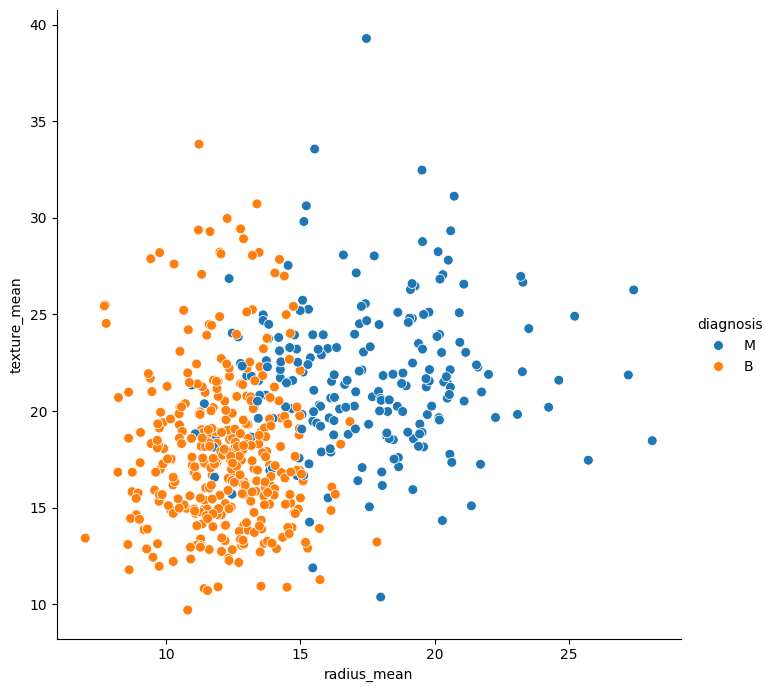

In [6]:
#Clasificación con base en 2 atibutos
sns.pairplot(x_vars='radius_mean', y_vars='texture_mean', data=tumor, plot_kws={'s': 50}, height=7, hue='diagnosis')


In [7]:
#Separar base en atributos y etiquetas

# Set de características
x = tumor.iloc[:, 2:8].values # 0, 1, 2, 3
x

array([[1.799e+01, 1.038e+01, 1.228e+02, 1.001e+03, 1.184e-01, 2.776e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, 1.326e+03, 8.474e-02, 7.864e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, 1.203e+03, 1.096e-01, 1.599e-01],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, 8.581e+02, 8.455e-02, 1.023e-01],
       [2.060e+01, 2.933e+01, 1.401e+02, 1.265e+03, 1.178e-01, 2.770e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, 1.810e+02, 5.263e-02, 4.362e-02]])

In [9]:
# Columna de respuestas
y = tumor.iloc[:, 1].values
y

array(['M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M',
       'M', 'M', 'M', 'M', 'M', 'M', 'B', 'B', 'B', 'M', 'M', 'M', 'M',
       'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'B', 'M',
       'M', 'M', 'M', 'M', 'M', 'M', 'M', 'B', 'M', 'B', 'B', 'B', 'B',
       'B', 'M', 'M', 'B', 'M', 'M', 'B', 'B', 'B', 'B', 'M', 'B', 'M',
       'M', 'B', 'B', 'B', 'B', 'M', 'B', 'M', 'M', 'B', 'M', 'B', 'M',
       'M', 'B', 'B', 'B', 'M', 'M', 'B', 'M', 'M', 'M', 'B', 'B', 'B',
       'M', 'B', 'B', 'M', 'M', 'B', 'B', 'B', 'M', 'M', 'B', 'B', 'B',
       'B', 'M', 'B', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B',
       'M', 'M', 'M', 'B', 'M', 'M', 'B', 'B', 'B', 'M', 'M', 'B', 'M',
       'B', 'M', 'M', 'B', 'M', 'M', 'B', 'B', 'M', 'B', 'B', 'M', 'B',
       'B', 'B', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B',
       'M', 'B', 'B', 'B', 'B', 'M', 'M', 'B', 'M', 'B', 'B', 'M', 'M',
       'B', 'B', 'M', 'M', 'B', 'B', 'B', 'B', 'M', 'B', 'B', 'M

In [10]:
#División de la base en entrenamiento 80% y prueba 20%

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [11]:
# Conjunto de entrenamiento
len(x_train)

455

In [12]:
# Conjunto de pruebas
len(x_test)

114

In [13]:
#Elección de K

import math
math.sqrt(len(x_train))

21.330729007701542

In [14]:
# Normalizar datos
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(x_train) # Construimos las equivalencias

MinMaxScaler()

In [15]:
#Escalar variables

x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)
x_test

array([[0.07998485, 0.1602976 , 0.07345726, 0.03550371, 0.42087542,
        0.08006301],
       [0.22618202, 0.28508624, 0.21567272, 0.12199364, 0.51102422,
        0.13615506],
       [0.20251787, 0.34223876, 0.19010435, 0.10375398, 0.35277506,
        0.08475447],
       [0.21056368, 0.25701725, 0.20641283, 0.10795334, 0.61442381,
        0.25847545],
       [0.282976  , 0.29015894, 0.27910994, 0.1619088 , 0.22678397,
        0.20412985],
       [0.24747977, 0.1481231 , 0.24179393, 0.13510074, 0.30900402,
        0.20152729],
       [0.47796867, 0.58978695, 0.46582821, 0.33399788, 0.50342131,
        0.31374563],
       [0.60717497, 0.42069665, 0.59574321, 0.47359491, 0.49614424,
        0.28532292],
       [0.19731175, 0.11396686, 0.18713289, 0.10112407, 0.48778104,
        0.10872543],
       [0.10823986, 0.10686507, 0.12231359, 0.04462354, 1.20310633,
        0.70036299],
       [0.23422784, 0.39972946, 0.22624559, 0.12517497, 0.48930162,
        0.20241764],
       [0.52103744, 0

In [16]:
x_train.min(), x_train.max()

(np.float64(0.0), np.float64(1.0))

In [21]:
# Importar clasificador

from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors=22)
classifier.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=22)

In [22]:
# Realizar predicción

y_pred = classifier.predict(x_test)
y_pred

array(['B', 'B', 'B', 'B', 'B', 'B', 'M', 'M', 'B', 'B', 'B', 'M', 'B',
       'B', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'M', 'B', 'B',
       'B', 'B', 'B', 'B', 'B', 'B', 'M', 'M', 'B', 'B', 'B', 'M', 'B',
       'M', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'M', 'B', 'B', 'M', 'B',
       'M', 'B', 'B', 'B', 'M', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'B',
       'M', 'M', 'B', 'B', 'B', 'B', 'B', 'M', 'M', 'B', 'M', 'B', 'M',
       'M', 'B', 'B', 'M', 'B', 'B', 'M', 'M', 'B', 'B', 'B', 'M', 'B',
       'B', 'B', 'M', 'B', 'M', 'B', 'M', 'B', 'B', 'B', 'M', 'B', 'M',
       'M', 'M', 'M', 'M', 'B', 'B', 'B', 'M', 'B', 'B'], dtype=object)

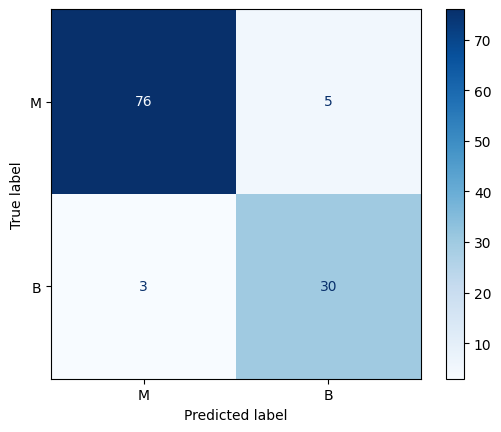

In [23]:
#Verificación de resultados

from sklearn.metrics import ConfusionMatrixDisplay
class_names = ['M', 'B']
normalize = None
ConfusionMatrixDisplay.from_estimator(
        classifier,
        x_test,
        y_test,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )

In [24]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           B       0.96      0.94      0.95        81
           M       0.86      0.91      0.88        33

    accuracy                           0.93       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



In [25]:
# Número de errores con distintas K

error = []

for i in range(1, 50):
    knn = KNeighborsClassifier(n_neighbors = i)
    knn.fit(x_train, y_train)
    pred_i = knn.predict(x_test)
    error.append(np.mean(pred_i != y_test))

error

[np.float64(0.09649122807017543),
 np.float64(0.07017543859649122),
 np.float64(0.07894736842105263),
 np.float64(0.06140350877192982),
 np.float64(0.07017543859649122),
 np.float64(0.05263157894736842),
 np.float64(0.07017543859649122),
 np.float64(0.07017543859649122),
 np.float64(0.07017543859649122),
 np.float64(0.07017543859649122),
 np.float64(0.07894736842105263),
 np.float64(0.07894736842105263),
 np.float64(0.07894736842105263),
 np.float64(0.06140350877192982),
 np.float64(0.07017543859649122),
 np.float64(0.06140350877192982),
 np.float64(0.05263157894736842),
 np.float64(0.06140350877192982),
 np.float64(0.06140350877192982),
 np.float64(0.07017543859649122),
 np.float64(0.07017543859649122),
 np.float64(0.07017543859649122),
 np.float64(0.07017543859649122),
 np.float64(0.06140350877192982),
 np.float64(0.06140350877192982),
 np.float64(0.06140350877192982),
 np.float64(0.06140350877192982),
 np.float64(0.06140350877192982),
 np.float64(0.06140350877192982),
 np.float64(0.

(0.0, 0.2)

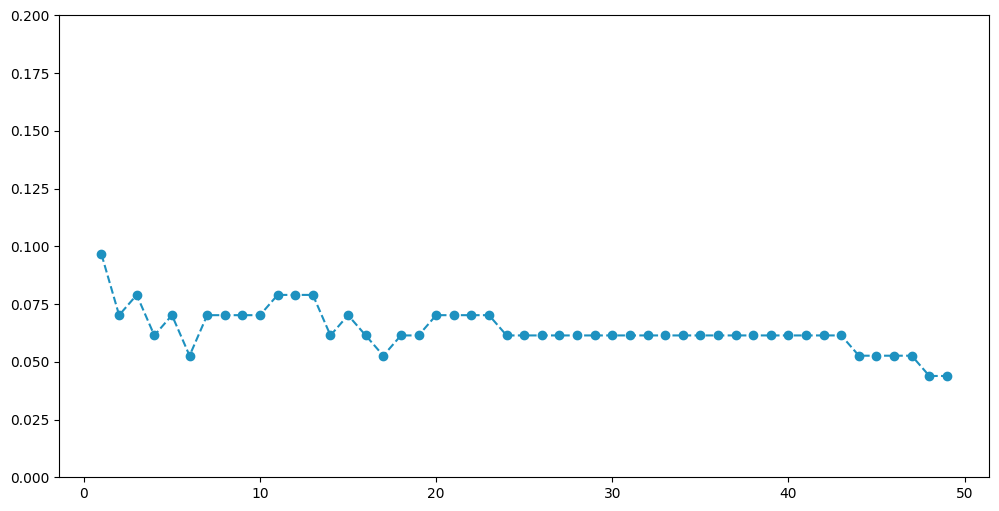

In [26]:
plt.figure(figsize = (12, 6))
plt.plot(range(1, 50), error, color = '#1d91c0', linestyle = 'dashed', marker = 'o')
plt.ylim(0, 0.2)

# Challenge: Wine Quality data

## Objetivo:
Determinar la calidad del vino con base en su características

1. Aplicar el algoritmo de KNN a Wine Quality Data que se encuentra dentro del siguiente link 👇🏼

> https://archive.ics.uci.edu/ml/datasets/Wine+Quality

2. Evaluar el rendimiento del modelo

In [30]:
# Descargar e importar la base de datos, se elije la winequality-red

winer = pd.read_csv('/content/sample_data/winequality-red.csv')
winer.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


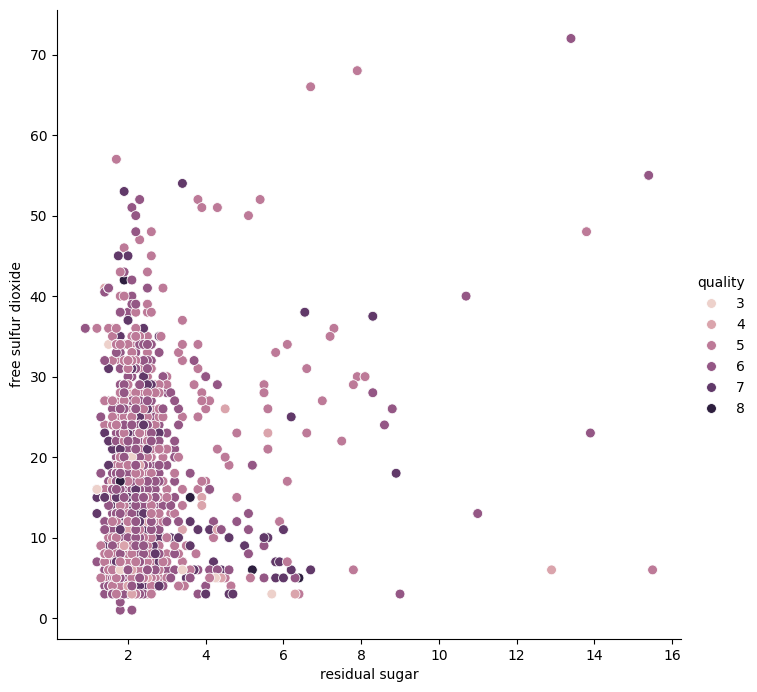

In [32]:
#Clasificación con base en 2 atibutos
sns.pairplot(x_vars='residual sugar', y_vars='free sulfur dioxide', data=winer, plot_kws={'s': 50}, height=7, hue='quality')

In [35]:
#Separar base en atributos y etiquetas

# Set de características
x = winer.iloc[:, :11].values
x

array([[ 7.4  ,  0.7  ,  0.   , ...,  3.51 ,  0.56 ,  9.4  ],
       [ 7.8  ,  0.88 ,  0.   , ...,  3.2  ,  0.68 ,  9.8  ],
       [ 7.8  ,  0.76 ,  0.04 , ...,  3.26 ,  0.65 ,  9.8  ],
       ...,
       [ 6.3  ,  0.51 ,  0.13 , ...,  3.42 ,  0.75 , 11.   ],
       [ 5.9  ,  0.645,  0.12 , ...,  3.57 ,  0.71 , 10.2  ],
       [ 6.   ,  0.31 ,  0.47 , ...,  3.39 ,  0.66 , 11.   ]])

In [37]:
# Columna de respuestas
y = winer.iloc[:, 11].values
y

array([5, 5, 5, ..., 6, 5, 6])

In [38]:
#División de la base en entrenamiento 80% y prueba 20%

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [39]:
# Conjunto de entrenamiento
len(x_train)

1279

In [40]:
# Conjunto de pruebas
len(x_test)

320

In [41]:
#Elección de K

import math
math.sqrt(len(x_train))

35.76310948449533

In [42]:
# Normalizar datos
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(x_train) # Construimos las equivalencias

MinMaxScaler()

In [43]:
#Escalar variables

x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)
x_test

array([[0.4       , 0.1369863 , 0.57      , ..., 0.42519685, 0.25766871,
        0.35384615],
       [0.11818182, 0.16438356, 0.24      , ..., 0.65354331, 0.12269939,
        0.50769231],
       [0.21818182, 0.65068493, 0.09      , ..., 0.44094488, 0.12269939,
        0.09230769],
       ...,
       [0.23636364, 0.29452055, 0.24      , ..., 0.55905512, 0.25153374,
        0.16923077],
       [0.17272727, 0.37671233, 0.02      , ..., 0.58267717, 0.09202454,
        0.16923077],
       [0.5       , 0.21917808, 0.42      , ..., 0.50393701, 0.3006135 ,
        0.23076923]])

In [44]:
x_train.min(), x_train.max()

(np.float64(0.0), np.float64(1.0000000000000002))

In [45]:
# Importar clasificador

from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors=36)
classifier.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=36)

In [46]:
# Realizar predicción

y_pred = classifier.predict(x_test)
y_pred

array([6, 6, 5, 5, 6, 5, 5, 5, 5, 6, 5, 7, 5, 5, 6, 5, 5, 5, 5, 6, 5, 5,
       5, 5, 6, 6, 5, 6, 6, 5, 5, 5, 6, 6, 6, 5, 6, 5, 6, 6, 5, 6, 6, 5,
       5, 5, 5, 5, 5, 6, 6, 6, 6, 5, 6, 5, 6, 6, 5, 5, 6, 6, 5, 6, 5, 5,
       6, 5, 5, 5, 6, 5, 5, 6, 5, 6, 6, 5, 5, 5, 6, 6, 6, 5, 5, 6, 6, 5,
       6, 5, 6, 5, 5, 6, 7, 6, 6, 5, 6, 7, 5, 6, 6, 6, 6, 6, 5, 6, 6, 6,
       5, 5, 5, 5, 6, 5, 6, 5, 5, 5, 5, 6, 5, 6, 7, 5, 5, 6, 6, 5, 7, 7,
       5, 6, 6, 5, 6, 5, 5, 6, 6, 5, 6, 5, 5, 6, 5, 7, 5, 5, 6, 6, 6, 6,
       6, 5, 5, 5, 6, 6, 5, 6, 5, 6, 5, 6, 5, 6, 5, 5, 5, 6, 6, 5, 5, 5,
       6, 5, 5, 5, 5, 5, 6, 5, 5, 6, 5, 6, 5, 5, 6, 5, 6, 7, 5, 5, 6, 6,
       5, 5, 6, 5, 5, 5, 7, 6, 5, 5, 6, 6, 7, 5, 5, 5, 5, 5, 6, 6, 5, 6,
       6, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 5, 5, 6, 5, 6, 6, 6, 6, 5,
       7, 5, 5, 5, 5, 5, 5, 6, 6, 5, 6, 5, 6, 6, 5, 6, 6, 7, 5, 5, 5, 6,
       6, 5, 7, 6, 6, 7, 6, 6, 6, 5, 7, 5, 5, 5, 5, 6, 6, 6, 5, 6, 6, 5,
       6, 5, 7, 6, 5, 5, 5, 5, 6, 7, 5, 5, 5, 6, 6,

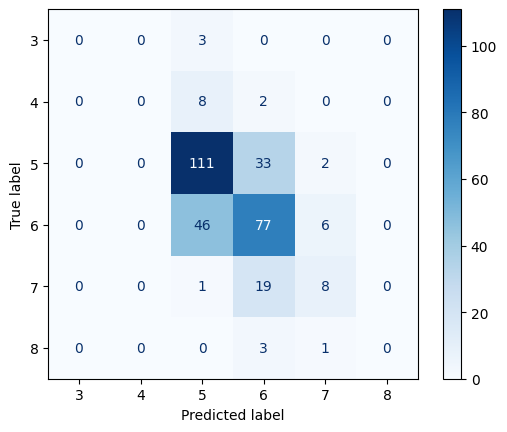

In [48]:
#Verificación de resultados

from sklearn.metrics import ConfusionMatrixDisplay
class_names = ['3', '4', '5', '6', '7', '8']
normalize = None
ConfusionMatrixDisplay.from_estimator(
        classifier,
        x_test,
        y_test,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )

In [49]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00        10
           5       0.66      0.76      0.70       146
           6       0.57      0.60      0.59       129
           7       0.47      0.29      0.36        28
           8       0.00      0.00      0.00         4

    accuracy                           0.61       320
   macro avg       0.28      0.27      0.27       320
weighted avg       0.57      0.61      0.59       320



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [50]:
# Número de errores con distintas K

error = []

for i in range(1, 50):
    knn = KNeighborsClassifier(n_neighbors = i)
    knn.fit(x_train, y_train)
    pred_i = knn.predict(x_test)
    error.append(np.mean(pred_i != y_test))

error

[np.float64(0.371875),
 np.float64(0.396875),
 np.float64(0.4),
 np.float64(0.4),
 np.float64(0.415625),
 np.float64(0.434375),
 np.float64(0.4125),
 np.float64(0.409375),
 np.float64(0.40625),
 np.float64(0.403125),
 np.float64(0.4),
 np.float64(0.4),
 np.float64(0.39375),
 np.float64(0.390625),
 np.float64(0.415625),
 np.float64(0.4125),
 np.float64(0.4),
 np.float64(0.39375),
 np.float64(0.4),
 np.float64(0.4),
 np.float64(0.396875),
 np.float64(0.375),
 np.float64(0.39375),
 np.float64(0.396875),
 np.float64(0.390625),
 np.float64(0.3875),
 np.float64(0.384375),
 np.float64(0.38125),
 np.float64(0.375),
 np.float64(0.390625),
 np.float64(0.375),
 np.float64(0.375),
 np.float64(0.36875),
 np.float64(0.3875),
 np.float64(0.38125),
 np.float64(0.3875),
 np.float64(0.384375),
 np.float64(0.3875),
 np.float64(0.390625),
 np.float64(0.3875),
 np.float64(0.3875),
 np.float64(0.378125),
 np.float64(0.3875),
 np.float64(0.375),
 np.float64(0.36875),
 np.float64(0.365625),
 np.float64(0.3781

(0.0, 0.45)

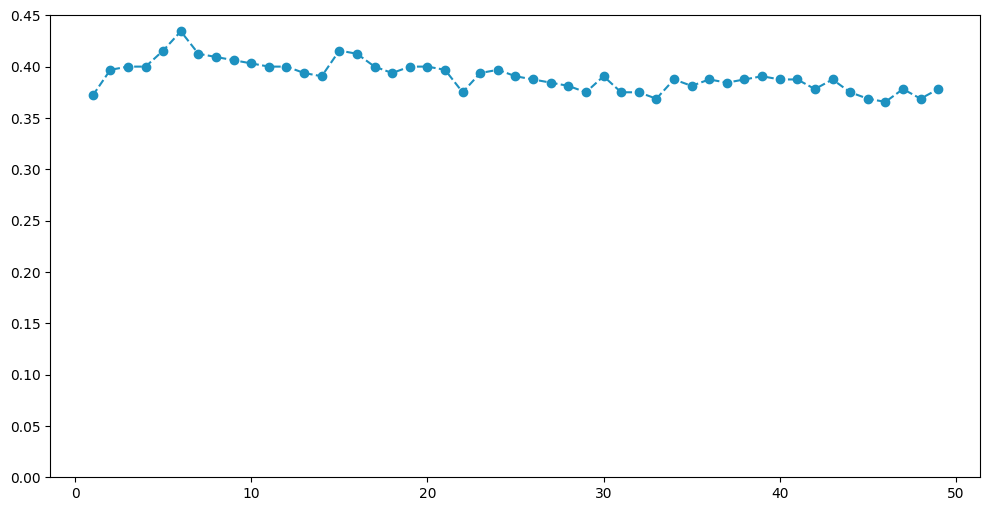

In [52]:
plt.figure(figsize = (12, 6))
plt.plot(range(1, 50), error, color = '#1d91c0', linestyle = 'dashed', marker = 'o')
plt.ylim(0, 0.45)

Se percibe una mejor clasificación en tumores como beningos y malignos que en la calidad del vino rojo.